In [ ]:
# Calculate z-scores manually: (x - mean) / std
import pandas as pd
import numpy as np
from scipy import stats



input_file = "../data/nigeria.csv"      
output_file = "../data/nigeria_clean.csv"
country_name = "Nigeria"

df = pd.read_csv(input_file)
df["Country"] = "Nigeria"

df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df["Year"] = df["Date"].dt.year

In [ ]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month,Year
0,2015,1,19.56,28.99,12.09,16.90,0.00,45.32,3.12,4.76,83.68,6.88,Kenya,2015-01-01,1,2015
1,2015,2,19.63,29.77,11.04,18.73,0.00,38.76,3.23,4.35,83.67,5.85,Kenya,2015-01-02,1,2015
2,2015,3,20.40,30.57,11.71,18.86,0.00,41.75,3.46,4.68,83.69,6.65,Kenya,2015-01-03,1,2015
3,2015,4,21.33,31.20,13.02,18.18,3.49,51.87,2.29,4.00,83.62,8.60,Kenya,2015-01-04,1,2015
4,2015,5,20.41,29.52,12.38,17.14,1.79,48.04,1.77,4.05,83.54,7.64,Kenya,2015-01-05,1,2015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026,86,19.37,25.40,15.39,10.01,2.67,81.97,2.47,3.90,84.08,13.40,Kenya,2026-03-27,3,2026
4104,2026,87,19.66,26.40,15.24,11.16,0.59,77.40,1.98,3.37,84.02,12.68,Kenya,2026-03-28,3,2026
4105,2026,88,19.72,26.54,14.41,12.13,0.82,77.71,1.77,3.25,83.88,12.92,Kenya,2026-03-29,3,2026
4106,2026,89,19.68,26.81,13.86,12.95,4.59,79.29,2.01,3.32,83.87,13.16,Kenya,2026-03-30,3,2026


In [ ]:
dupes = df.duplicated().sum()
print(f"Duplicate rows: {dupes}")
df.drop_duplicates(inplace=True)

Duplicate rows: 0


In [ ]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month,Year
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000,4108.000000
mean,2020.131451,180.121227,20.427600,27.838717,14.673169,13.165548,1.468162,65.845355,3.061765,4.375241,83.724335,11.052539,2020-08-15 12:00:00,6.423564,2020.131451
min,2015.000000,1.000000,15.260000,18.880000,8.970000,4.110000,0.000000,28.420000,0.610000,1.160000,83.310000,4.780000,2015-01-01 00:00:00,1.000000,2015.000000
25%,2017.000000,86.000000,19.460000,26.297500,13.700000,11.467500,0.100000,58.677500,2.420000,3.670000,83.630000,9.880000,2017-10-23 18:00:00,3.000000,2017.000000
50%,2020.000000,179.000000,20.360000,27.875000,14.750000,13.260000,0.380000,66.220000,3.140000,4.430000,83.720000,11.005000,2020-08-15 12:00:00,6.000000,2020.000000
75%,2023.000000,272.000000,21.400000,29.520000,15.750000,15.050000,1.360000,73.280000,3.720000,5.090000,83.810000,12.350000,2023-06-08 06:00:00,9.000000,2023.000000
max,2026.000000,366.000000,25.400000,34.270000,18.750000,20.120000,51.650000,91.070000,5.280000,7.590000,84.170000,15.040000,2026-03-31 00:00:00,12.000000,2026.000000
std,3.248907,106.294767,1.440824,2.358770,1.415691,2.605174,3.180228,9.934196,0.853218,0.992156,0.126391,1.607151,NaN,3.477046,3.248907


In [ ]:
missing = df.isna().sum()
missing_pct = 100 * missing / len(df)
print(pd.concat([missing, missing_pct], axis=1, keys=['count', '%']))

             count    %
YEAR             0  0.0
DOY              0  0.0
T2M              0  0.0
T2M_MAX          0  0.0
T2M_MIN          0  0.0
T2M_RANGE        0  0.0
PRECTOTCORR      0  0.0
RH2M             0  0.0
WS2M             0  0.0
WS2M_MAX         0  0.0
PS               0  0.0
QV2M             0  0.0
Country          0  0.0
Date             0  0.0
Month            0  0.0
Year             0  0.0


In [ ]:
cols = ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
z_scores = np.abs(stats.zscore(df[cols].dropna()))  
outliers = (z_scores > 3).sum(axis=0)
print(outliers)

[ 8  3  9 92  6  0  6]


In [ ]:
weather_cols = ['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
df[weather_cols] = df[weather_cols].ffill()
output_file = "../data/nigeria_clean.csv"
# Drop rows that still have >30% missing values (after ffill)
threshold = 0.3 * len(df.columns)
before_drop = len(df)
df.dropna(thresh=len(df.columns) - threshold, inplace=True)
print(f"Rows dropped due to >30% missing: {before_drop - len(df)}")

df.to_csv(output_file, index=False)
print(f"Cleaned data saved to {output_file}")

Rows dropped due to >30% missing: 0
Cleaned data saved to ../data/kenya_clean.csv


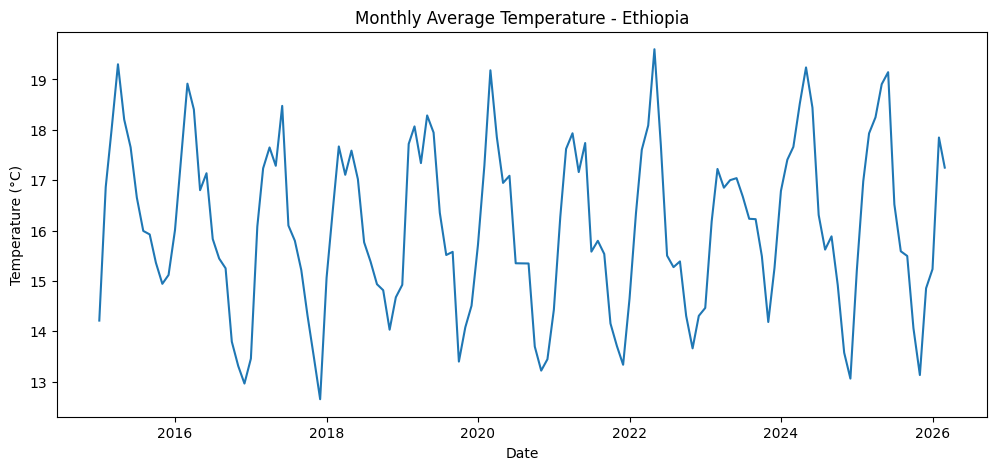

In [ ]:
import matplotlib.pyplot as plt
df_clean = pd.read_csv("../data/ethiopia_clean.csv")
df_clean['Date'] = pd.to_datetime(df_clean['Date'])
monthly_t2m = df_clean.groupby(['Year','Month'])['T2M'].mean().reset_index()
monthly_t2m['Date'] = pd.to_datetime(monthly_t2m[['Year','Month']].assign(day=1))

plt.figure(figsize=(12,5))
plt.plot(monthly_t2m['Date'], monthly_t2m['T2M'])
plt.title('Monthly Average Temperature - Ethiopia')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

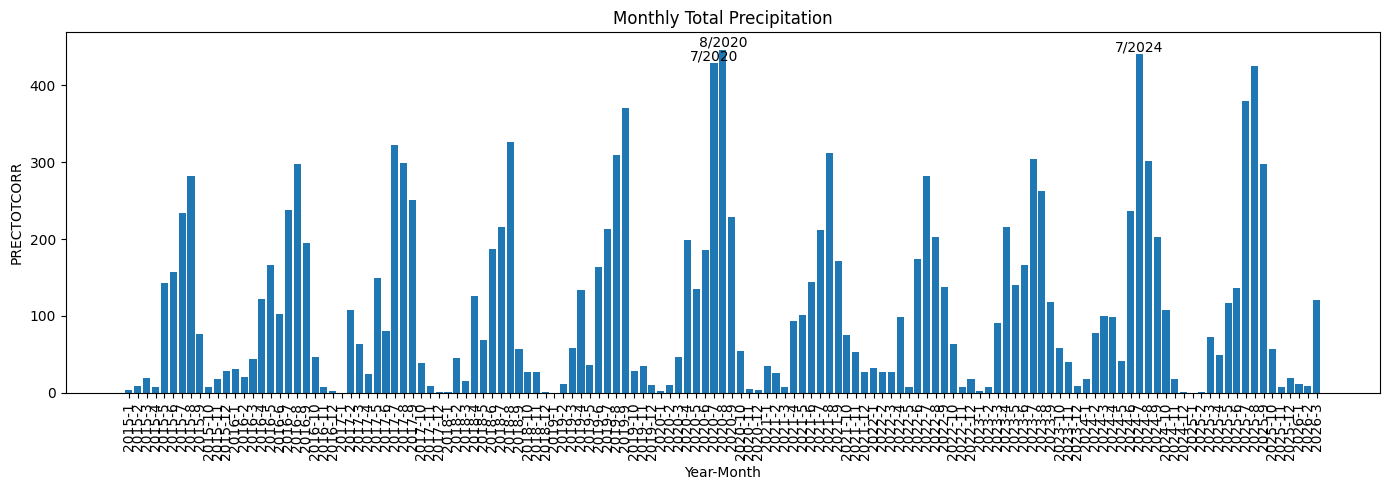

In [ ]:
import matplotlib.pyplot as plt

monthly_precip = df_clean.groupby(['Year','Month'])['PRECTOTCORR'].sum().reset_index()

# create label like 2020-01
monthly_precip['YM'] = monthly_precip['Year'].astype(str) + '-' + monthly_precip['Month'].astype(str)

plt.figure(figsize=(14,5))
plt.bar(monthly_precip['YM'], monthly_precip['PRECTOTCORR'])

# find peak months
top = monthly_precip.nlargest(3, 'PRECTOTCORR')

# annotate
for _, row in top.iterrows():
    plt.text(
        x=monthly_precip.index[monthly_precip['YM']==row['YM']][0],
        y=row['PRECTOTCORR'],
        s=f"{row['Month']}/{row['Year']}",
        ha='center',
        va='bottom'
    )

plt.xticks(rotation=90)
plt.title('Monthly Total Precipitation')
plt.ylabel('PRECTOTCORR')
plt.xlabel('Year-Month')

plt.tight_layout()
plt.show()

<Axes: >

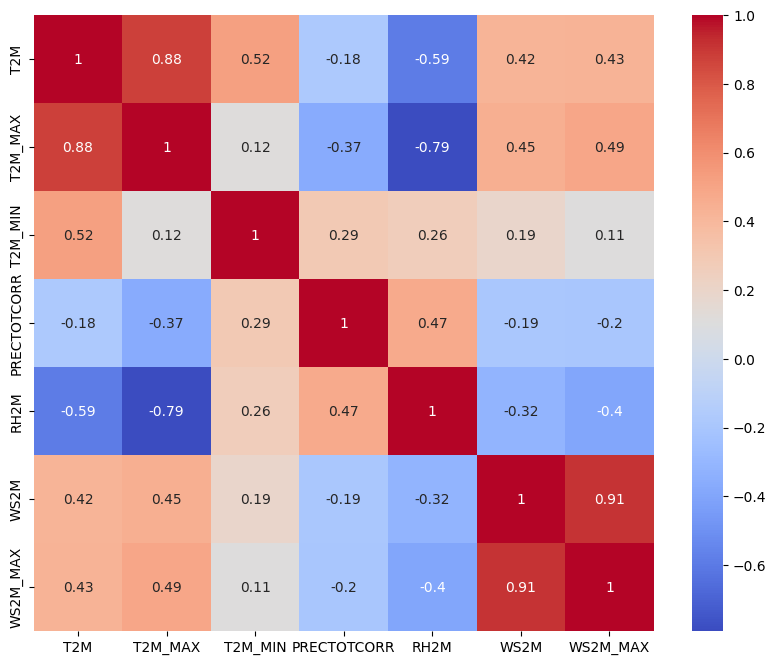

In [ ]:
import seaborn as sns
plt.figure(figsize=(10,8))
sns.heatmap(df[weather_cols].corr(), annot=True, cmap='coolwarm')

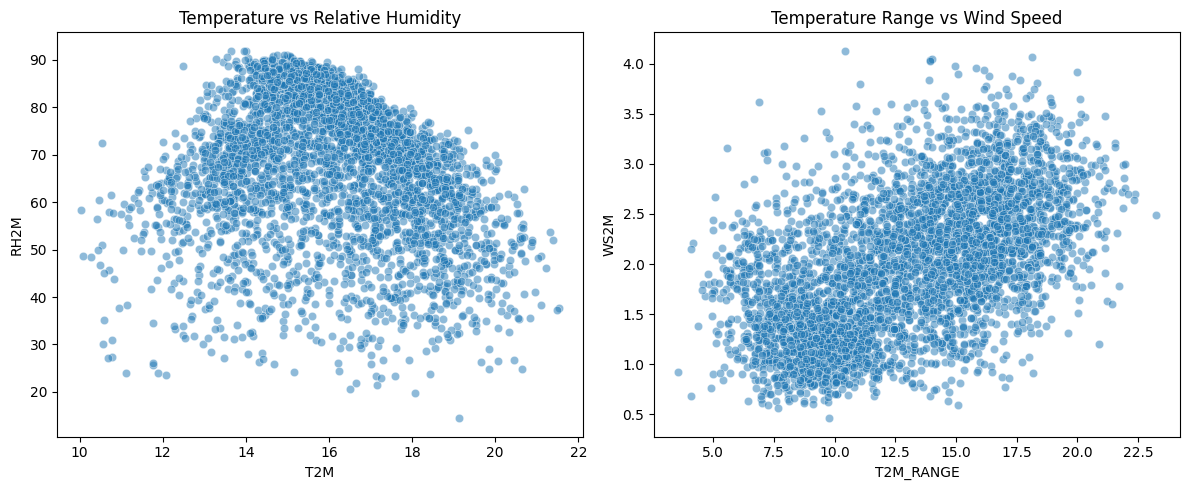

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a new column for temperature range
df_clean['T2M_RANGE'] = df_clean['T2M_MAX'] - df_clean['T2M_MIN']

# Create the two scatter plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot 1: Temperature vs Humidity
sns.scatterplot(data=df_clean, x='T2M', y='RH2M', ax=axes[0], alpha=0.5)
axes[0].set_title('Temperature vs Relative Humidity')

# Plot 2: Temperature range vs Wind speed
sns.scatterplot(data=df_clean, x='T2M_RANGE', y='WS2M', ax=axes[1], alpha=0.5)
axes[1].set_title('Temperature Range vs Wind Speed')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Rainfall distribution (log scale)')

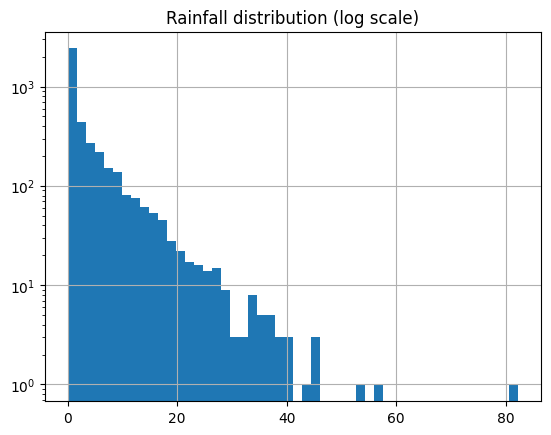

In [ ]:
df_clean['PRECTOTCORR'].hist(bins=50, log=True)
plt.title('Rainfall distribution (log scale)')

Text(0, 0.5, 'Relative Humidity (%)')

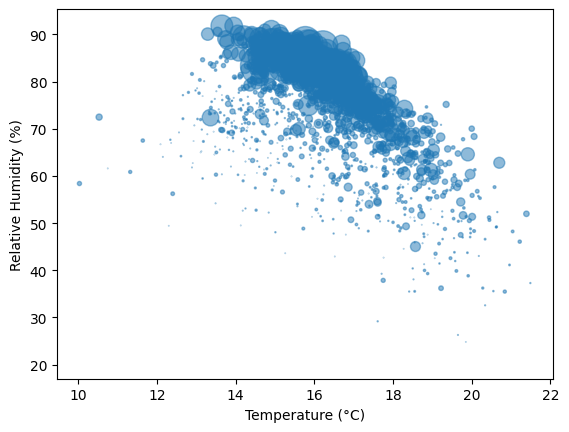

In [13]:
sample = df_clean.sample(min(2000, len(df_clean)))
plt.scatter(sample['T2M'], sample['RH2M'], s=sample['PRECTOTCORR']*10, alpha=0.5)
plt.xlabel('Temperature (°C)'); plt.ylabel('Relative Humidity (%)')